262144


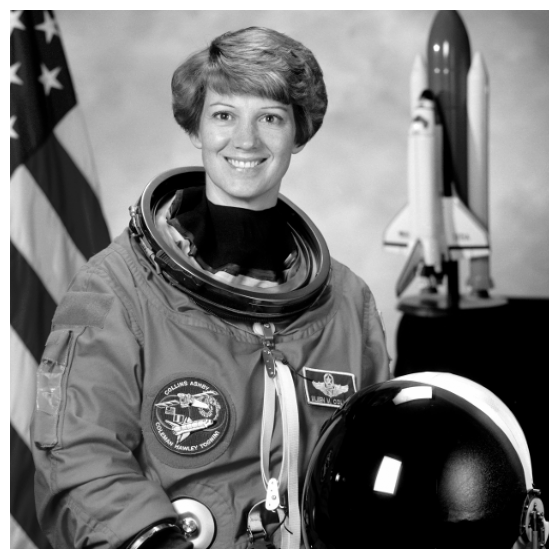

In [1]:
import skimage as si
import skimage.color as sc
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as ss
from scipy.sparse.linalg import LinearOperator, eigsh
import scipy.optimize as so
from algorithms import Algorithms
import time
import pywt
from skimage.metrics import peak_signal_noise_ratio as psnr


img = sc.rgb2gray( si.data.astronaut() )

print( np.prod( img.shape ) )

plt.figure( figsize = ( 7, 7 ) )
plt.imshow( img, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [2]:
N_kernel = 7
kernel = np.full( ( N_kernel, N_kernel ), 1 / ( N_kernel ** 2 ) )

def A( x ):
    return ss.convolve2d( x, kernel, mode = "same" )

def A_transpose( x ):
    return ss.correlate2d( x, kernel, mode = "same" )

def ATA( x ):
    return A_transpose( A( x ) )

In [3]:
#testando se AT é adjunta de A ( y'Ax = x'ATy )

x = np.random.standard_normal( size = img.shape )
y = np.random.standard_normal( size = img.shape )

print( ( y * A( x ) ).sum() )
print( ( x * A_transpose( y ) ).sum() )

#okay

67.88349851295257
67.8834985129526


In [4]:
img_borrada = A( img )


In [5]:
#vendo se H é adjunta de HT (y'Hx = x'HTy) e se HT é a inversa de H

def H( x, wavelet = 'db5' ):
  return pywt.coeffs_to_array( pywt.wavedec2( x, wavelet = wavelet, mode = 'periodization' ) )

def HT( c, wavelet = 'db5' ):
  return pywt.waverec2( pywt.array_to_coeffs( *c, output_format = 'wavedec2' ), wavelet = wavelet, mode = 'periodization' )

Hx = H( x )

print( np.sum( y * Hx[ 0 ] ) )
print( np.sum( x * HT( ( y, Hx[ 1 ] ) ) ) )
print( np.abs( img - HT( H( img ) ) ).sum(  ) )
#para a imagem do café tem esse problema de que o pywt expande o tamanho da imagem, com isso H não é adjunta de HT ( encontrado o problema )
#para a imagem da astronauta tudo da certo

85.80075126791311
85.80075126791274
6.399910360449916e-11


In [6]:
#imagem borrada com ruído
rng = np.random.default_rng( 0 )

gauss_noise = rng.normal( 0, 0.01, img.shape )
b = img_borrada + gauss_noise

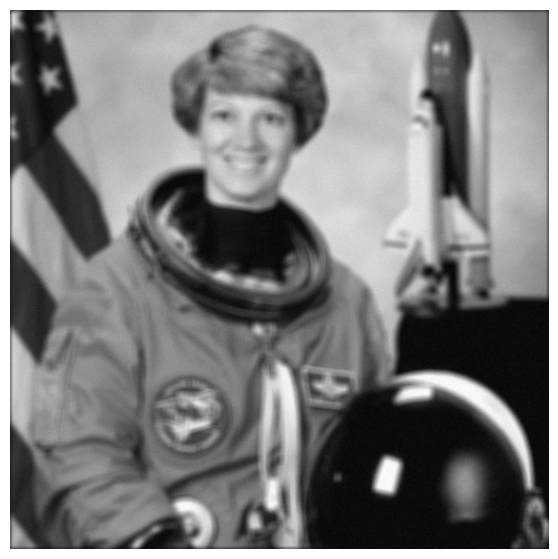

In [7]:
plt.figure( figsize = ( 7, 7 ) )
plt.imshow( b, cmap = plt.cm.gray )
plt.axis( "off" )
plt.show()

In [8]:
rows, cols = img_borrada.shape[ 0 ], img_borrada.shape[ 1 ]
dim = rows * cols

def mv( v ):
    x_2d = v.reshape( ( rows, cols ) )
    res_2d = ATA( x_2d )
    return res_2d.reshape( -1 )

operator = LinearOperator( ( dim, dim ), matvec = mv )

eigenvals, _ = eigsh( operator, k = 1, which = 'LM' )

norma_espectral = eigenvals[ 0 ]
print( f"Norma Espectral de A'A: {norma_espectral}" )
print( f'O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de { 1 / norma_espectral }' )

Norma Espectral de A'A: 0.9997013347066693
O tamanho de passo máximo para que o algoritmo seja garantido a convergir é de 1.0002987545209372


In [8]:
def f( x ):
    return 1/2 * ( (A( x ) - b) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

def g( x, wavelet = 'db5', **kwargs ):
  H_x, _ = H( x, wavelet )
  return np.sum( np.abs( H_x ) )

In [ ]:
# #usando o critério de quase-otimização ( qoc ) que encontrei no paper: Comparing parameter choice methods for regularization
# #of ill-posed problems Frank Bauer a , Mark A. Lukas b

# gammas = [ 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5 ] #os valores tem que estar ordenados
# step = 1
# x0 = np.zeros_like( b )
# prox = Algorithms.prox_wavelet
# tol = 1.0e-10
# max_iter = 100 

# kwargs = {'wavelet': 'db5'}


# iters_gammas = []
# for gamma in gammas:
#     iters = Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
#     iters_gammas.append( iters )

# best_x_gamma = []
# for iters in iters_gammas:
#     best_x_gamma.append( iters[ -1 ] )

# diffs_gamma = [ np.linalg.norm( best_x_gamma[ j ] - best_x_gamma[ j+1 ]) for j in range( len( best_x_gamma ) - 1 ) ]
# j_star = np.argmin( diffs_gamma )
# gamma_star = gammas[ j_star ]

# print( "Gamma ótimo:", gamma_star )


Gamma ótimo: 0.01


Gamma ótimo: 0.001
Menor erro absoluto atingido: 20.368316850149416


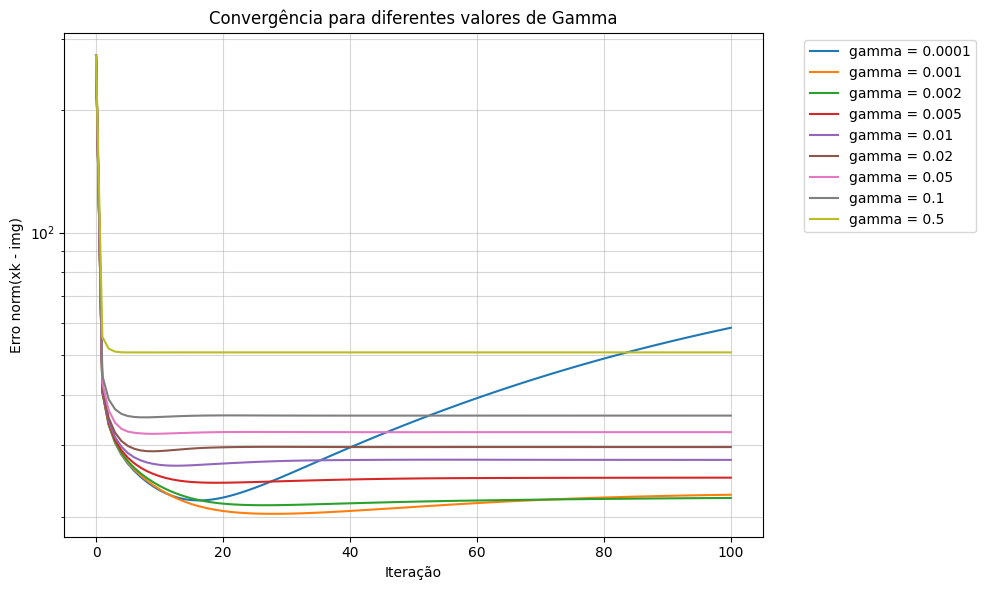

In [14]:
gammas = [ 0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5 ]
step = 1
x0 = np.zeros_like( b )
prox = Algorithms.prox_wavelet
tol = 1.0e-10
max_iter = 100 
kwargs = { 'wavelet': 'db5' }

min_errors = []
error_histories = {} 

for gamma in gammas:
    iters = Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, 
                                   gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
    
    errors_k = [ np.linalg.norm( xk - img ) for xk in iters ]
    
    error_histories[ gamma ] = errors_k 
    min_errors.append( min( errors_k ) )

idx_best = np.argmin( min_errors )
gamma_star = gammas[ idx_best ]

print( f"Gamma ótimo: {gamma_star}" )
print( f"Menor erro absoluto atingido: {min_errors[ idx_best ]}" )

plt.figure( figsize = ( 10, 6 ) )

for gamma in gammas:
    plt.plot( error_histories[ gamma ], label = f"gamma = {gamma}" )

plt.yscale( 'log' )
plt.xlabel( 'Iteração' )
plt.ylabel( 'Erro norm(xk - img)' )
plt.title( 'Convergência para diferentes valores de Gamma' )
plt.legend( bbox_to_anchor = ( 1.05, 1 ), loc = 'upper left' )
plt.grid( True, which = "both", ls = "-", alpha = 0.5 )
plt.tight_layout()

plt.show()

In [9]:
def compare_methods( methods, f, g, grad_f, prox, x0, gamma, img, max_iter = 1000, tol = 1e-2, **kwargs ):
    results = {}
    for name, method in methods.items():

        start_time = time.perf_counter()
        iters = method( f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        err_vals = [ np.abs( img - x ).sum() for x in iters ]
        F_vals = [ f( x ) + gamma * g( x, **kwargs ) for x in iters ]
        idx_best = np.argmin(err_vals)
        
        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "errors": err_vals,
            "F_values": F_vals,
            "final_image": iters[ idx_best ]
        }

    F_star = min( min( vals[ "F_values" ] ) for vals in results.values() )
    return results, F_star

def get_metrics( img_true, img_test ):
    p = psnr( img_true, img_test, data_range = img_true.max() - img_true.min() )
    return p


# Testando $\gamma = 0$ para ver se não há nenhum erro de implementação (algoritmos deveriam convergir)

In [10]:
step = 1
gamma = 0
x0 = np.zeros_like( b )

In [11]:
methods = {
    "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_backtracking(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
}

params_wav = {
    'wavelet': 'db5',
    'Q': ATA
}

results, F_star = compare_methods( methods, f, g, grad_f, Algorithms.prox_wavelet, x0, gamma, img, max_iter = 250, tol = 1e-2, **params_wav )

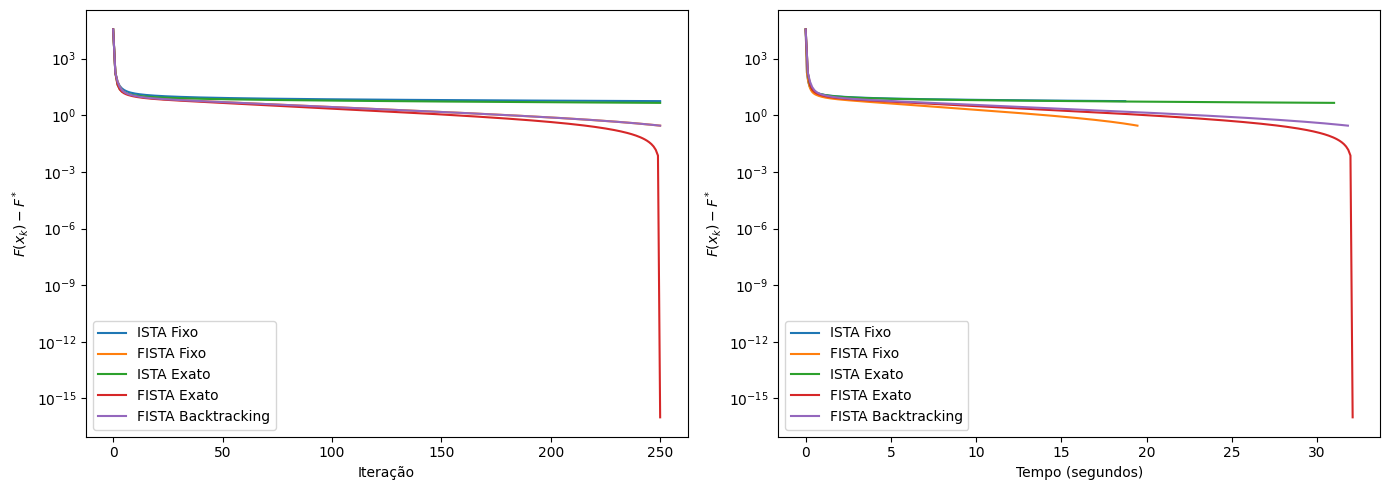

In [12]:
epsilon = 1e-16
names = [ "ISTA Fixo", "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "F_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()


plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "F_values" ] )
    diff_vals = vals - F_star + epsilon
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()


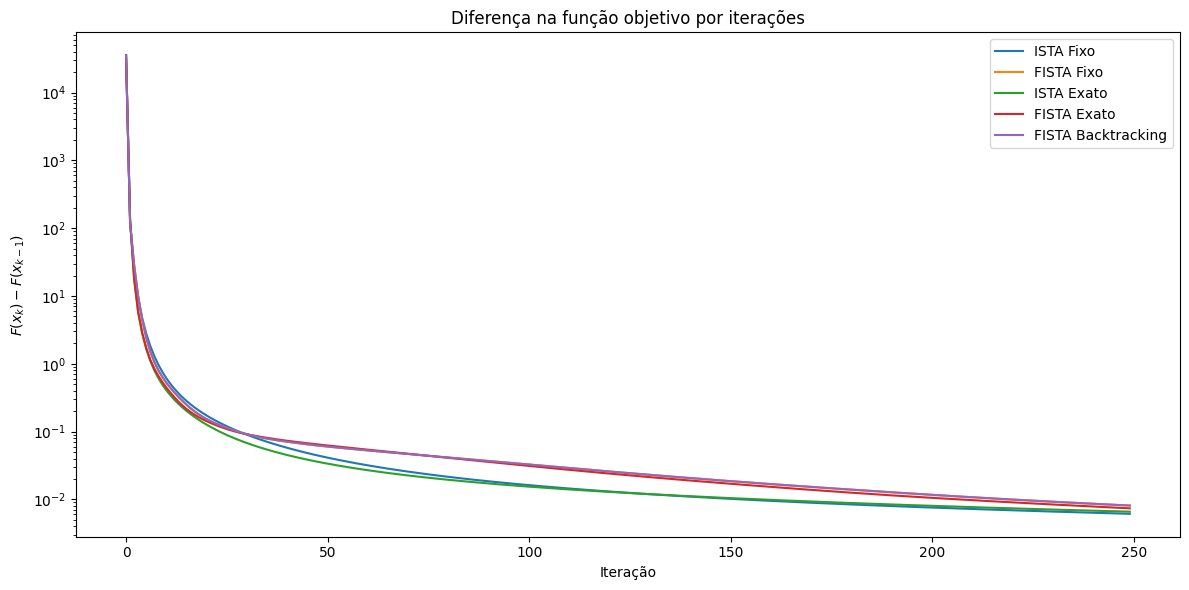

In [13]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

plt.figure( figsize = ( 12, 6 ) )
for name in names:
    deltas = delta_F( results[ name ][ "F_values" ] )
    plt.semilogy( deltas, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F(x_{k-1})$" )
plt.title("Diferença na função objetivo por iterações")
plt.tight_layout()
plt.show()

Note que todos convergem, logo a implementação parece estar correta

# Testando para o $\gamma = 0.001$ ótimo

In [15]:
step = 1
gamma = gamma_star
x0 = np.zeros_like( b )

In [16]:
methods = {
    "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_fixo( f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_backtracking(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
}

params_wav = {
    'wavelet': 'db5',
    'Q': ATA
}

results, F_star = compare_methods( methods, f, g, grad_f, Algorithms.prox_wavelet, x0, gamma, img, max_iter = 250, tol = 1e-2, **params_wav )
#mesmo com a A sendo adjunta a AT, H adjunta a HT e HT sendo a inversa de H, o fista utilizando o passo exato não converge


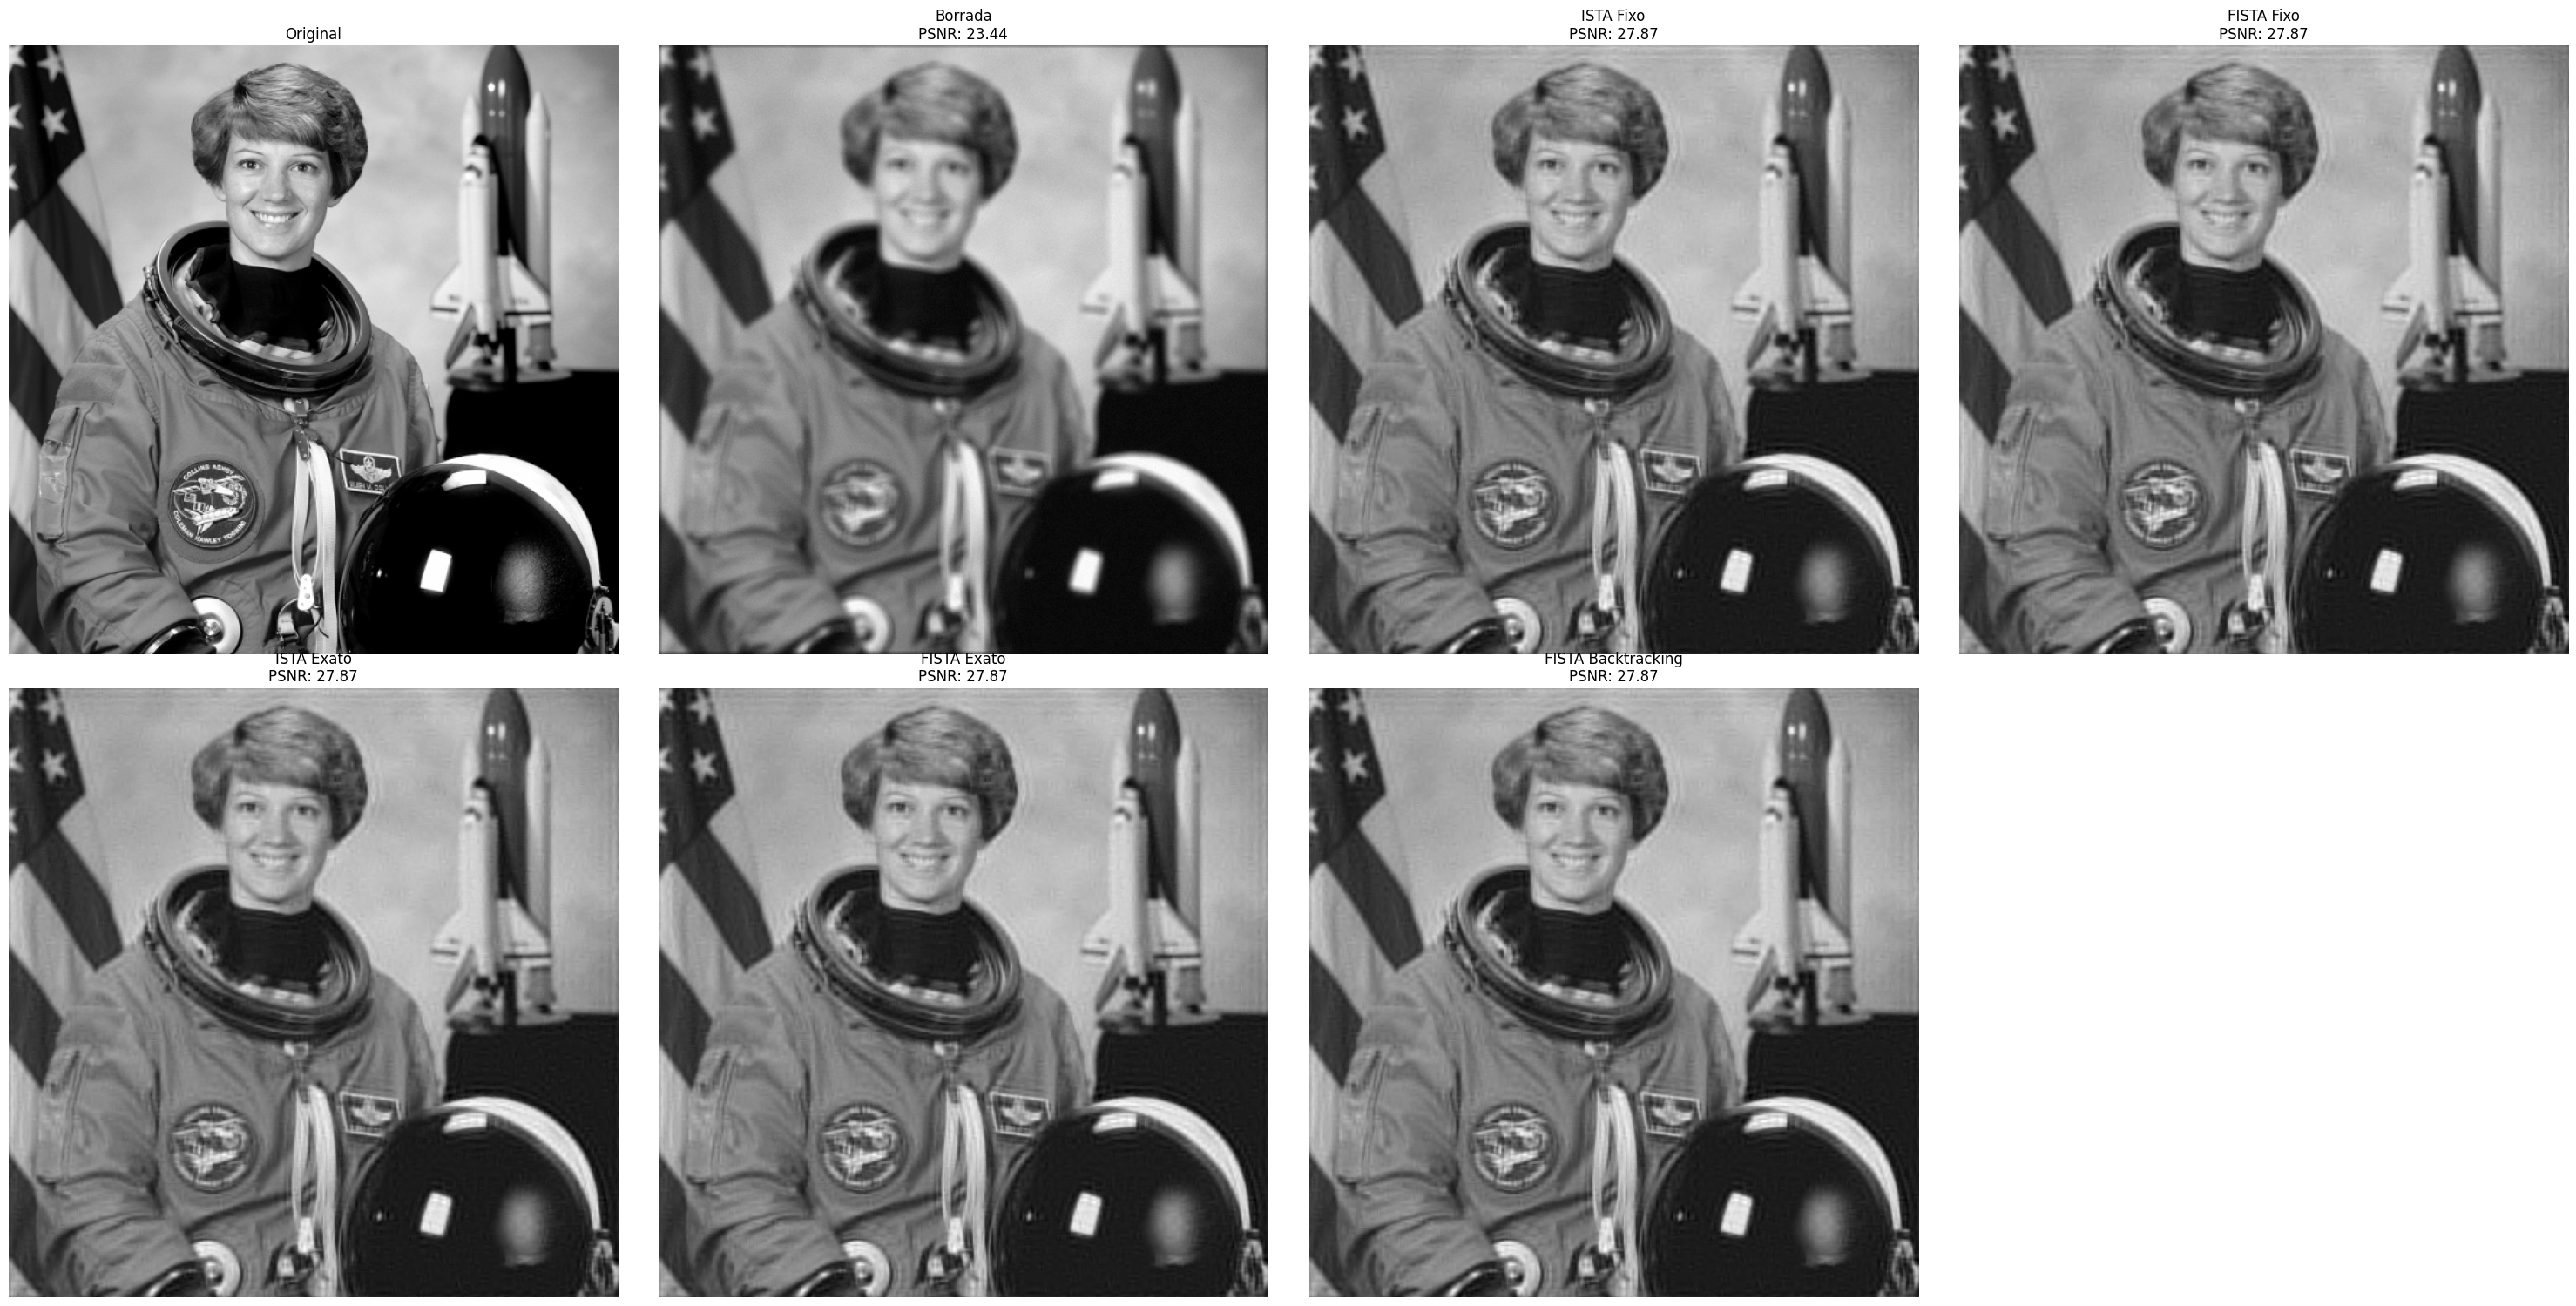

In [17]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "ISTA Fixo", "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img, cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img, b )
plt.subplot( 2, 4, 2 )
plt.imshow( b, cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    res_img = results[ name ][ "final_image" ]
    p = get_metrics( img, res_img )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    plt.title( f"{name}\nPSNR: {p:.2f}" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

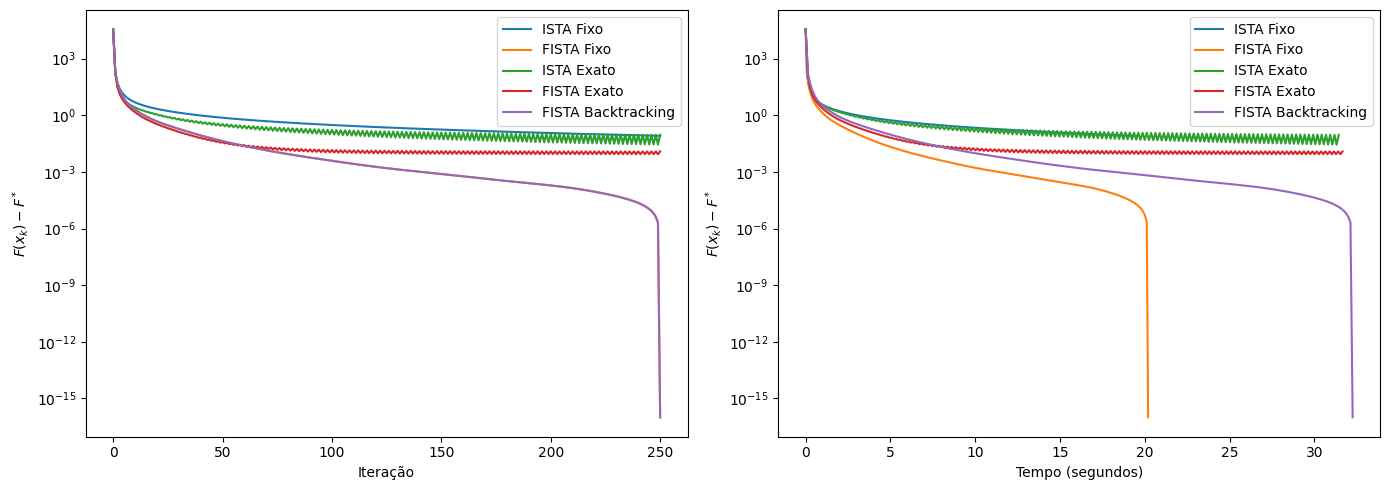

In [18]:
epsilon = 1e-16

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "F_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()


plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "F_values" ] )
    diff_vals = vals - F_star + epsilon
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()


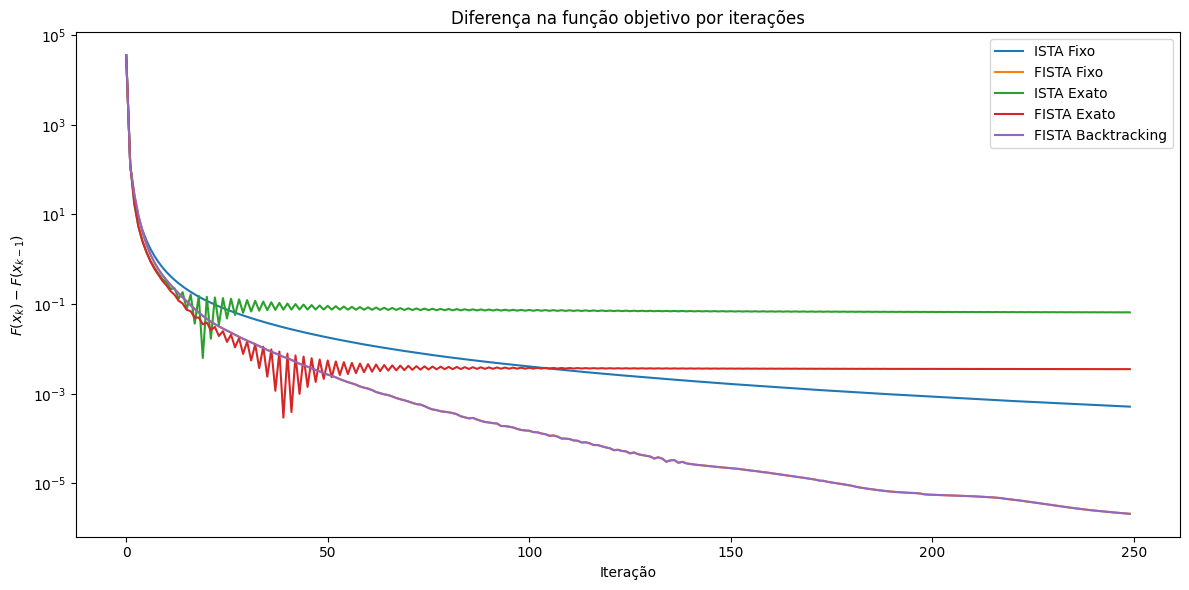

In [19]:
def delta_F( F_vals ):
    return [ abs( F_vals[ k ] - F_vals[ k-1 ] ) for k in range( 1, len( F_vals ) ) ]

plt.figure( figsize = ( 12, 6 ) )
for name in names:
    deltas = delta_F( results[ name ][ "F_values" ] )
    plt.semilogy( deltas, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F(x_{k-1})$" )
plt.title("Diferença na função objetivo por iterações")
plt.tight_layout()
plt.show()

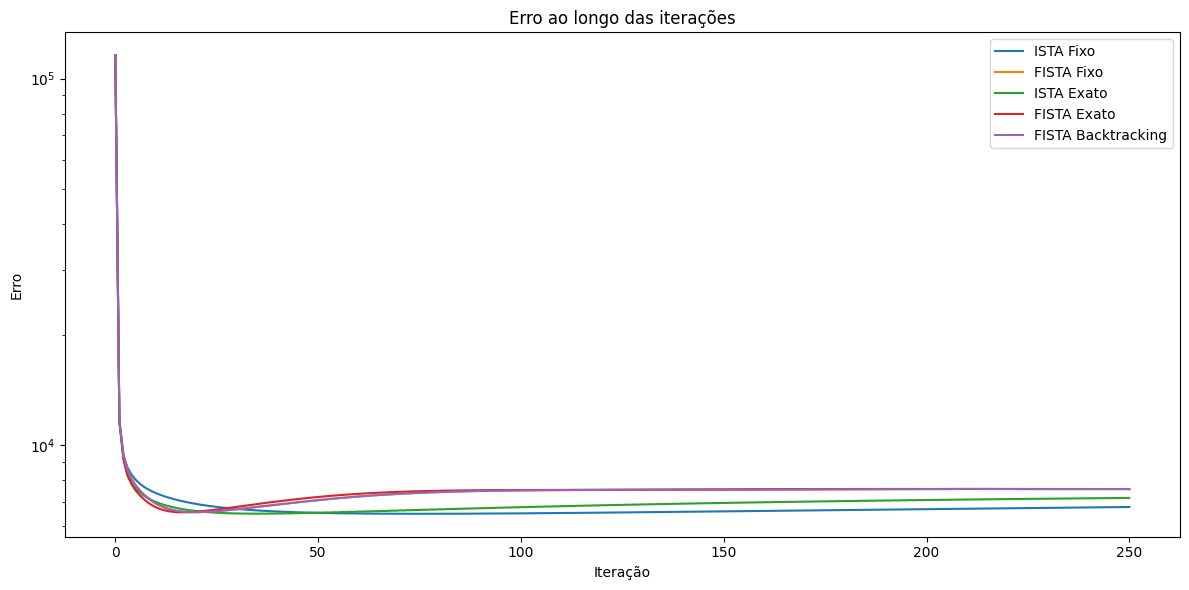

In [20]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = results[ name ][ "errors" ]
    plt.semilogy( vals, label = name )

plt.legend()
plt.xlabel( "Iteração" )
plt.ylabel( "Erro" )
plt.title( "Erro ao longo das iterações" )
plt.tight_layout()
plt.show()


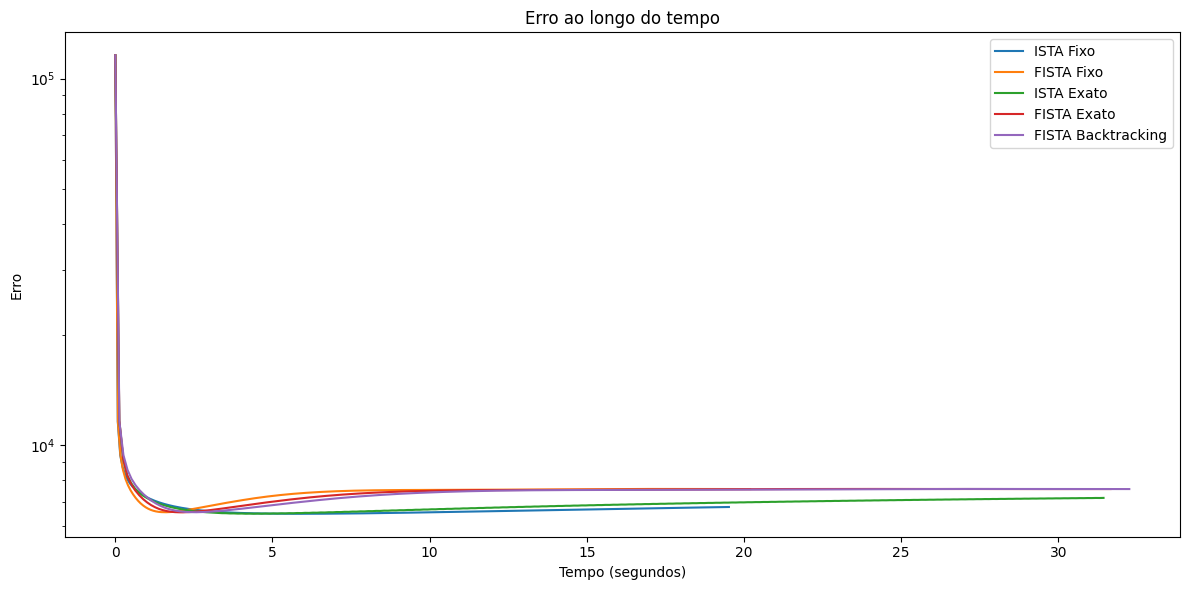

In [21]:
plt.figure( figsize = ( 12, 6 ) )

for name in names:
    vals = np.array( results[ name ][ "errors" ] )
    total_time = results[ name ][ "execution_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    plt.semilogy( times, vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Erro" )
plt.legend()
plt.title( "Erro ao longo do tempo" )
plt.tight_layout()
plt.show()


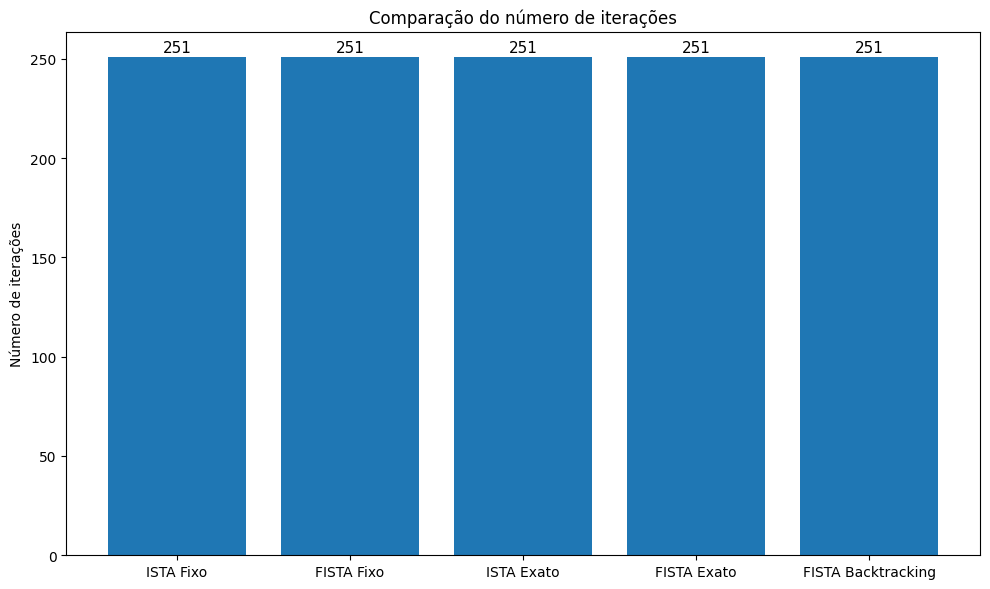

In [22]:
num_iters = [ results[ name ][ "iterations" ] for name in names ]

plt.figure( figsize = ( 10, 6 ) )
bars = plt.bar( names, num_iters )
plt.ylabel( "Número de iterações" )
plt.title( "Comparação do número de iterações" )

for bar in bars:
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width() / 2, height + 1, str( height ), ha = 'center', va = 'bottom', fontsize = 11 )
plt.tight_layout()
plt.show()


# Testando para diferentes valores de $\gamma$

In [13]:
x0 = np.zeros_like( b )
wav = 'db5'
prox = Algorithms.prox_wavelet
params_wav = {'wavelet': wav, 'Q': ATA}

In [14]:
gammas = [ 0.0001, 0.001, 0.01, 0.1, 0.2 ]

all_experiments = {}

for gm in gammas:
    print( f"gamma = {gm}:" )
    
    methods = {
        "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
            Algorithms.ista_exato( f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
         
         "ISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
            Algorithms.ista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = 1.0, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
       
        "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
            Algorithms.fista_exato( f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
        
        "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
            Algorithms.fista_backtracking( f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, step = 1.2, beta = 0.95, max_iter = max_iter, tol = tol, **kwargs)
    }

    res, F_star = compare_methods(
        methods = methods, f = f, g = g, grad_f = grad_f, prox = prox, x0 = x0, 
        gamma = gm, img = img, max_iter = 250, tol = 1e-2, **params_wav
    )
    
    all_experiments[ gm ] = {"results": res, "F_star": F_star}

gamma = 0.0001:
gamma = 0.001:
gamma = 0.01:
gamma = 0.1:
gamma = 0.2:


<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:28: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:28: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_14198/1670168332.py:16: SyntaxWarning: invalid escape sequence '\g'
  ax_iter.set_title( f"Convergência (Iterações) - $\gamma$ = {g_val}" )
/tmp/ipykernel_14198/1670168332.py:28: SyntaxWarning: invalid escape sequence '\g'
  ax_time.set_title( f"Convergência (Tempo) - $\gamma$ = {g_val}" )


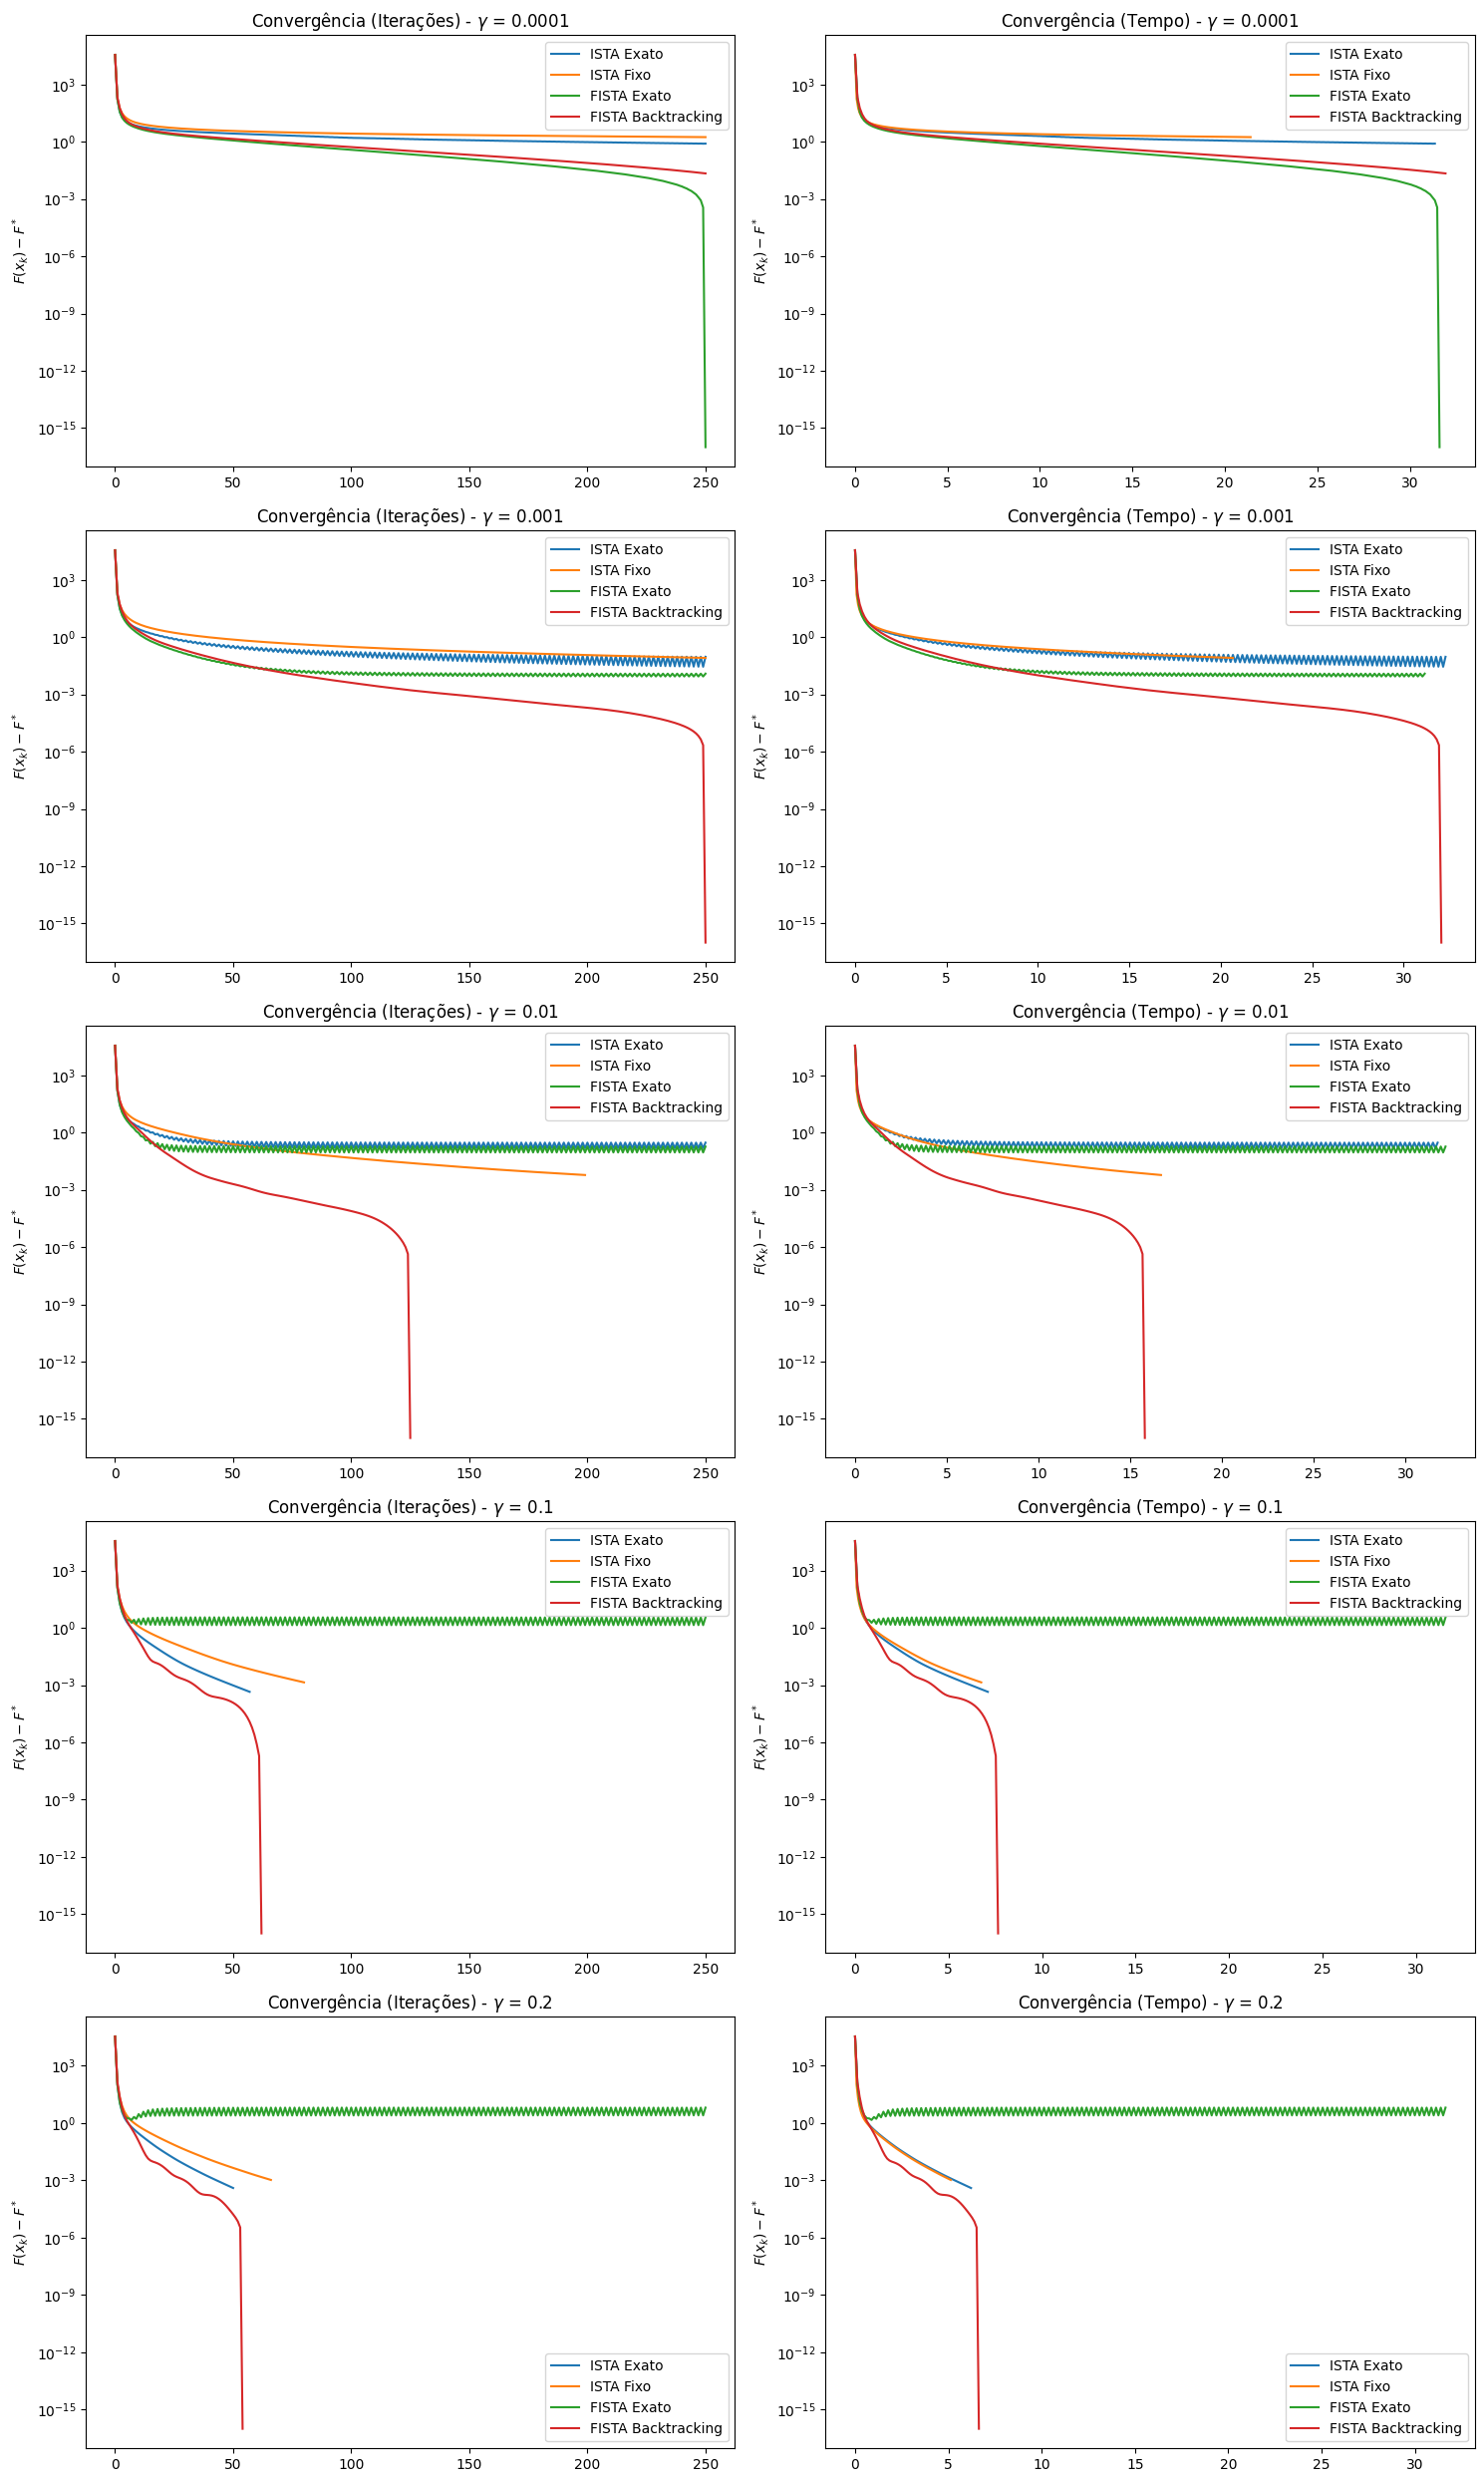

In [15]:
num_gammas = len( gammas )
fig, axes = plt.subplots( num_gammas, 2, figsize = ( 15, 5 * num_gammas ) )

epsilon = 1e-16

for i, g_val in enumerate( gammas ):
    res = all_experiments[ g_val ][ "results" ]
    F_star = all_experiments[ g_val ][ "F_star" ]
    
    ax_iter = axes[ i, 0 ]
    for name in res.keys():
        vals = res[ name ][ "F_values" ]
        diff_vals = [ max( F - F_star, epsilon ) for F in vals ]
        ax_iter.semilogy( diff_vals, label = name )
    
    ax_iter.set_title( f"Convergência (Iterações) - $\gamma$ = {g_val}" )
    ax_iter.set_ylabel( "$F(x_k) - F^*$" )
    ax_iter.legend()

    ax_time = axes[ i, 1 ]
    for name in res.keys():
        vals = np.array( res[ name ][ "F_values" ] )
        diff_vals = [ max( v - F_star, epsilon ) for v in vals ]
        total_time = res[ name ][ "execution_time" ]
        times = np.linspace( 0, total_time, len( vals ) )
        ax_time.semilogy( times, diff_vals, label = name )
    
    ax_time.set_title( f"Convergência (Tempo) - $\gamma$ = {g_val}" )
    ax_time.set_ylabel( "$F(x_k) - F^*$" )
    ax_time.legend()

plt.tight_layout()
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:34: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_14198/560639724.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax_iter.set_title( f"Estabilidade $|F(x_k) - F(x_{{k-1}})|$ - $\gamma$ = {g_val}" )
/tmp/ipykernel_14198/560639724.py:34: SyntaxWarning: invalid escape sequence '\g'
  ax_time.set_title( f"Estabilidade por Tempo - $\gamma$ = {g_val}" )


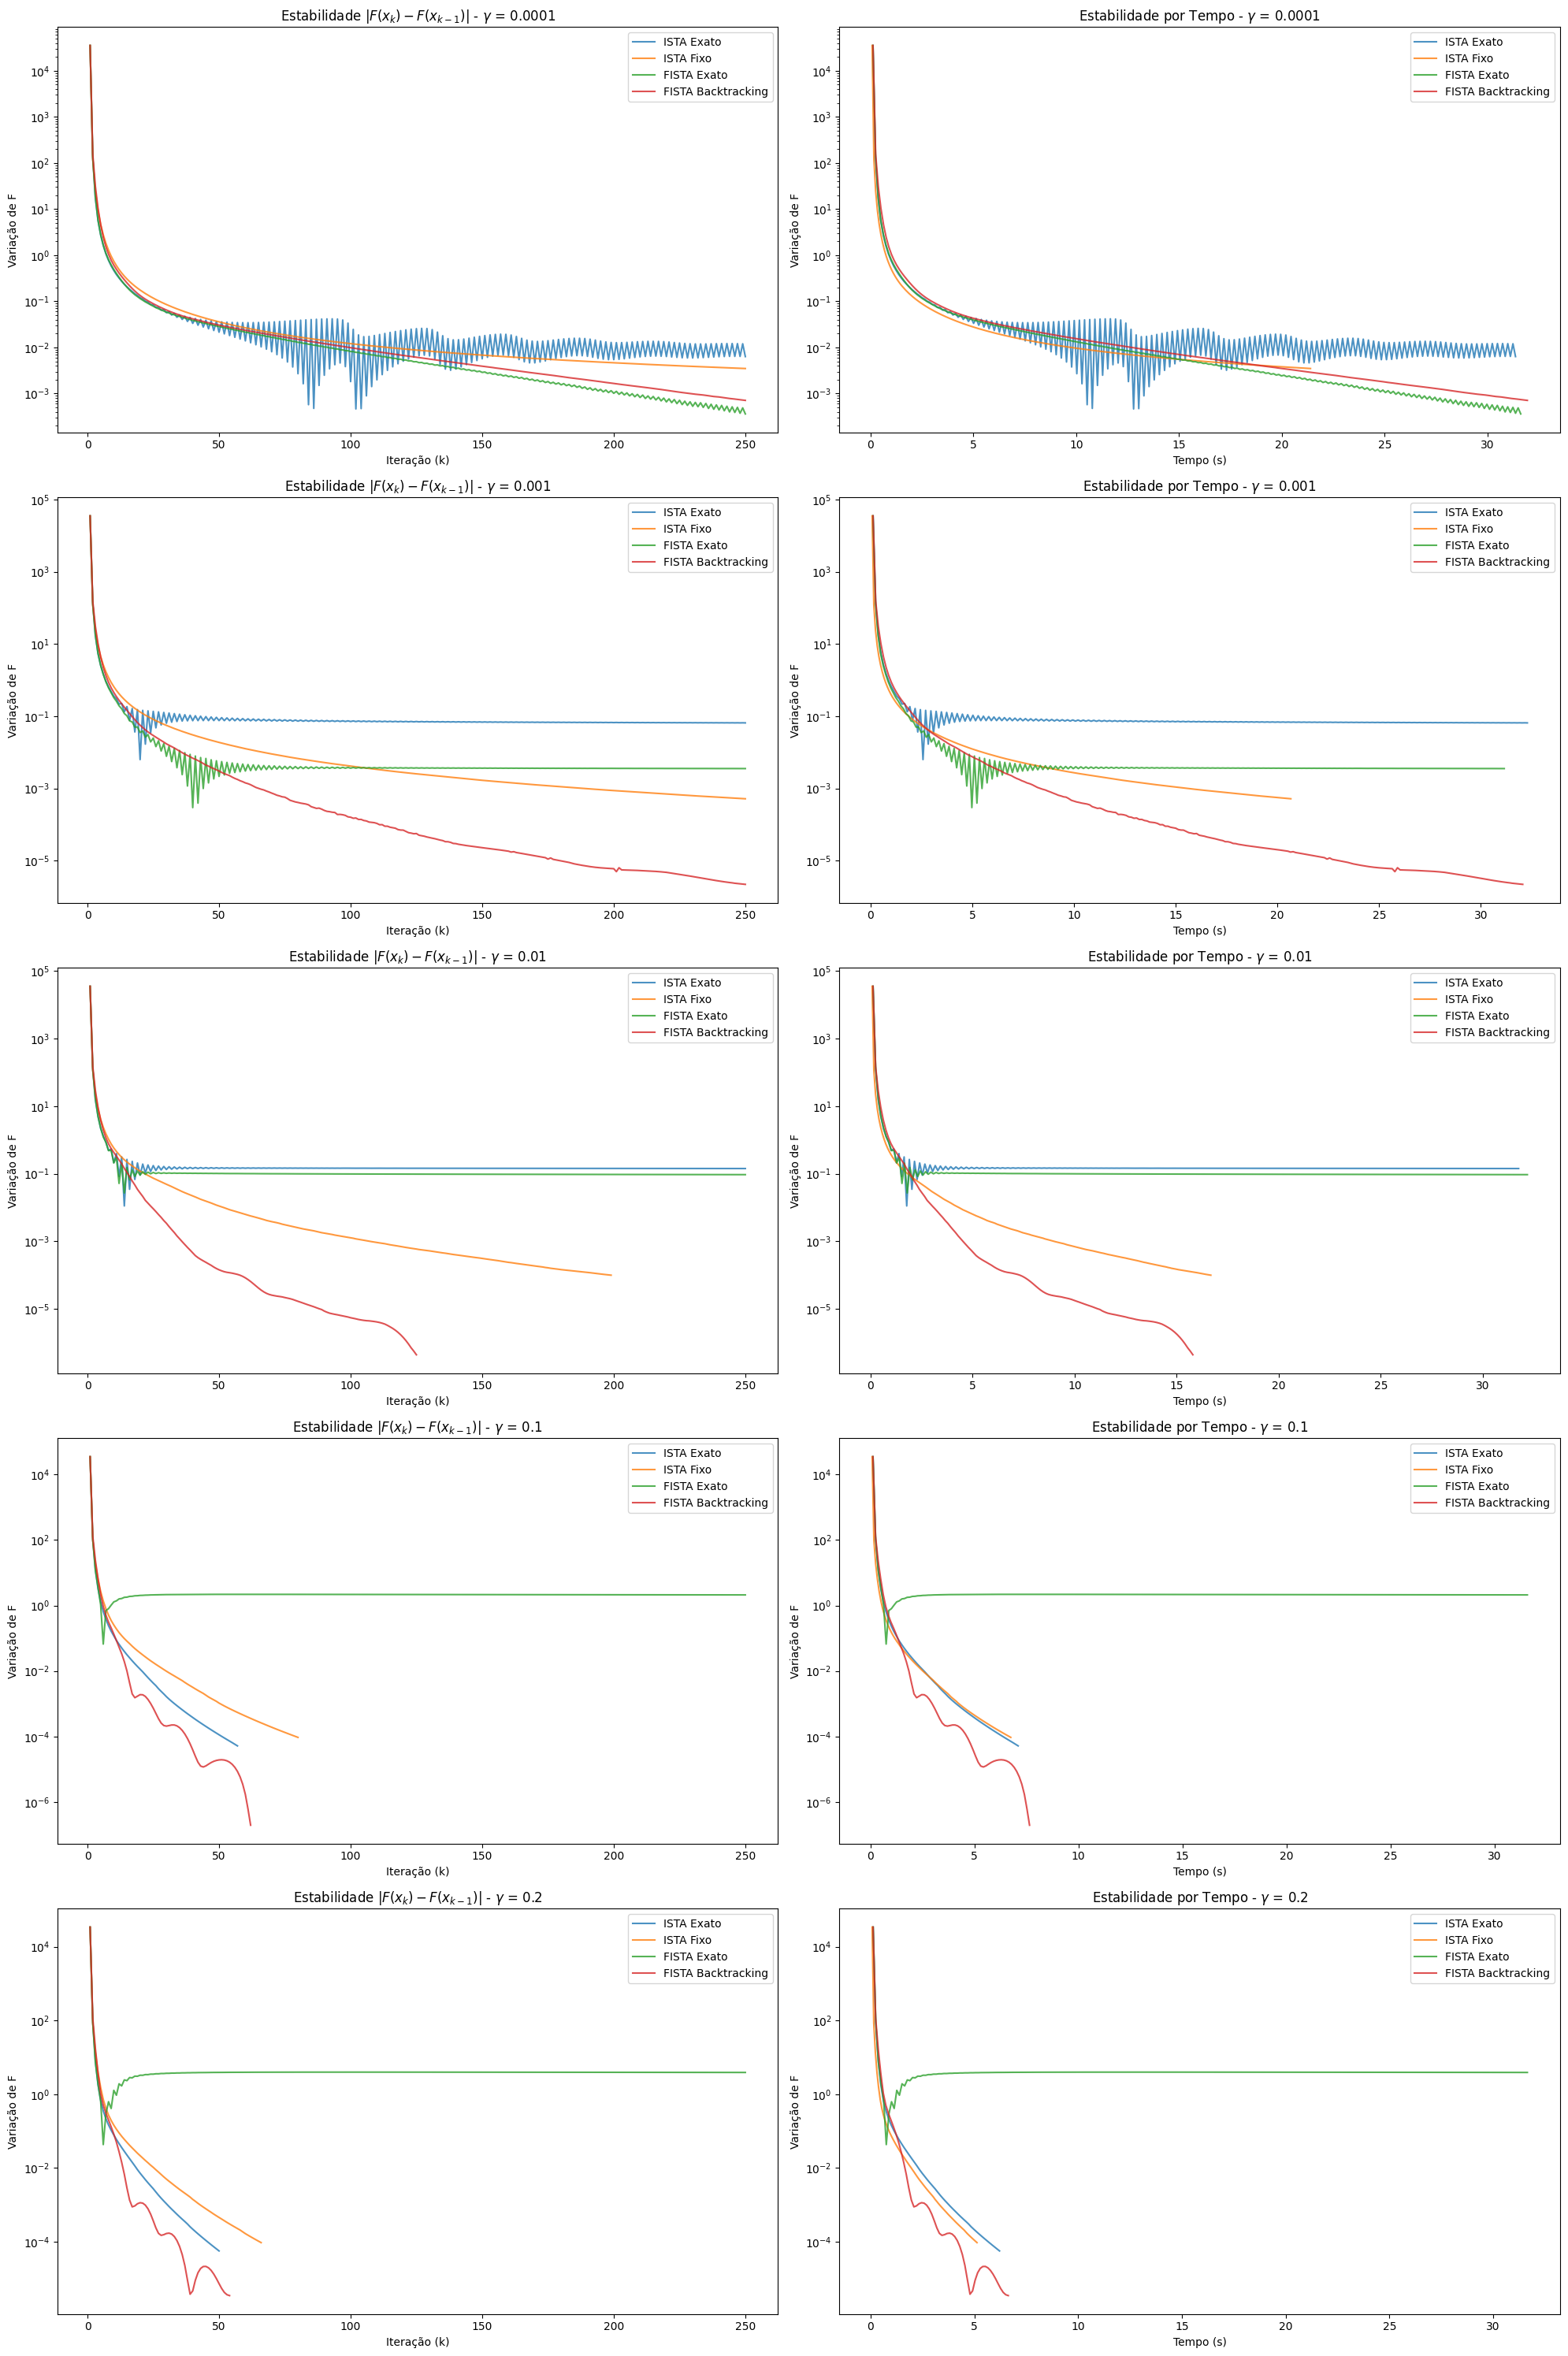

In [16]:
num_gammas = len( gammas )
fig, axes = plt.subplots( num_gammas, 2, figsize = ( 20, 6 * num_gammas ) )

epsilon = 1e-16 

for i, g_val in enumerate( gammas ):
    res = all_experiments[ g_val ][ "results" ]
    
    ax_iter = axes[ i, 0 ]
    for name in res.keys():
        vals = np.array( res[ name ][ "F_values" ] )
        
        diff_vals = np.abs( np.diff( vals ) )
        diff_vals = np.maximum( diff_vals, epsilon )
        
        ax_iter.semilogy( range( 1, len( vals ) ), diff_vals, label = name, alpha = 0.8 )
    
    ax_iter.set_title( f"Estabilidade $|F(x_k) - F(x_{{k-1}})|$ - $\gamma$ = {g_val}" )
    ax_iter.set_xlabel( "Iteração (k)" )
    ax_iter.set_ylabel( "Variação de F" )
    ax_iter.legend()

    ax_time = axes[ i, 1 ]
    for name in res.keys():
        vals = np.array( res[ name ][ "F_values" ] )
        diff_vals = np.abs( np.diff( vals ) )
        diff_vals = np.maximum( diff_vals, epsilon )
        
        total_time = res[ name ][ "execution_time" ]
        times = np.linspace( 0, total_time, len( vals ) )[ 1: ]
        
        ax_time.semilogy( times, diff_vals, label = name, alpha = 0.8 )
    
    ax_time.set_title( f"Estabilidade por Tempo - $\gamma$ = {g_val}" )
    ax_time.set_xlabel( "Tempo (s)" )
    ax_time.set_ylabel( "Variação de F" )
    ax_time.legend()

plt.tight_layout()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:12: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_14198/847297290.py:12: SyntaxWarning: invalid escape sequence '\g'
  plt.bar( x_pos + offset, iter_counts, bar_width, label = f"$\gamma$ = {g_val}" )
/tmp/ipykernel_14198/847297290.py:16: SyntaxWarning: invalid escape sequence '\g'
  plt.title( "Custo Computacional: Iterações totais por Método e $\gamma$" )


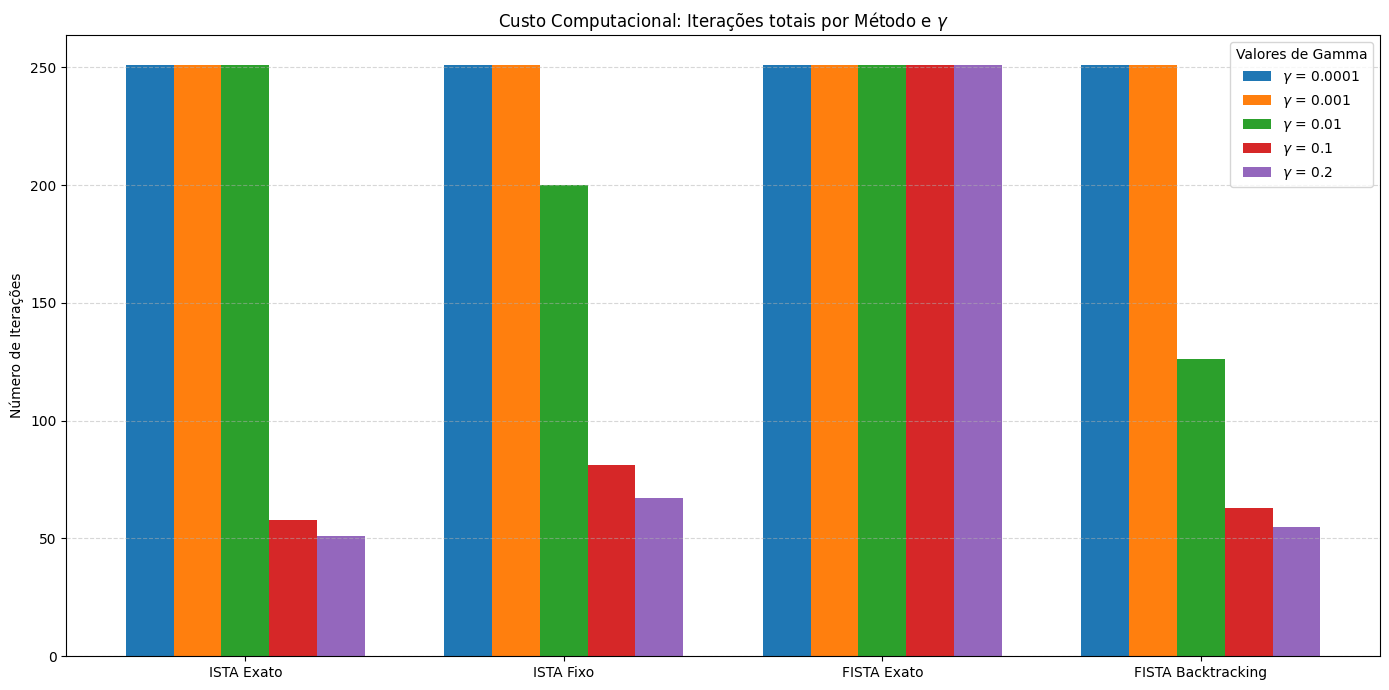

In [17]:
plt.figure( figsize = ( 14, 7 ) )

method_names = list( next( iter( all_experiments.values() ) )[ "results" ].keys() )
x_pos = np.arange( len( method_names ) )
bar_width = 0.15

for i, g_val in enumerate( gammas ):
    iter_counts = [ all_experiments[ g_val ][ "results" ][ name ][ "iterations" ] for name in method_names ]
    
    offset = ( i - len( gammas ) / 2 ) * bar_width + ( bar_width / 2 )
    
    plt.bar( x_pos + offset, iter_counts, bar_width, label = f"$\gamma$ = {g_val}" )

plt.xticks( x_pos, method_names )
plt.ylabel( "Número de Iterações" )
plt.title( "Custo Computacional: Iterações totais por Método e $\gamma$" )
plt.legend( title = "Valores de Gamma" )
plt.grid( axis = 'y', linestyle = '--', alpha = 0.5 )

plt.tight_layout()
plt.show()

Algumas conclusões:

- Para $\gamma$ muito pequeno (pelo menos para menores que $0.0001$) o problema se aproxima do problema sem regularização e portanto os algoritmos convergem;
- Para $\gamma = 0.001$ os algoritmos não convergem
- Para $\gamma > 0.1$ o FISTA com um relaxamento de $0.7 \times \lambda$ (onde $\lambda$ é o passo exato) faz com que o algoritmo convirja (por mais que ainda assim seja meio instável pra gamma = 0.1).

# Plotando os tamanhos de passo calculados ao utilizar busca exata

In [18]:
#alguns testes rapidos
def fista_exato( f, x0, Q, grad_f, prox, gamma, max_iter = 1000, tol = 1.0e-1, wavelet = 'haar'  ):
    y0 = x0.copy()
    x = x0.copy()
    iterations = 0
    t0 = 1
    iters = [ x.copy() ]
    dif = float( 'inf' )
    lbds = []
    while dif > tol and iterations < max_iter:
        x0 = x.copy()
        g_y = grad_f( y0 )
        num = np.sum( g_y * g_y )  
        den = np.sum( g_y * Q( g_y ) )
        step = num / den
        ygrad = y0 - step * g_y
    
        x = prox( x = ygrad, step = step, gamma = gamma, wavelet = wavelet )
        t = ( 1 + np.sqrt( 1 + 4*t0 ** 2 ) ) / 2
        y = x + ( ( t0 - 1 ) / ( t ) )  * ( x - x0 )
        
        dif = np.linalg.norm( x - x0 )


        y0 = y
        t0 = t
        iterations += 1
        iters.append( x.copy() )
        lbds.append( step )

    return iters, lbds

def ista_exato( f, x0, grad_f, prox, gamma, Q, max_iter = 1000, tol = 1.0e-1, wavelet = 'haar' ):
    x = x0.copy()
    iterations = 0
    iters = [ x.copy() ]
    dif = float( 'inf' )
    lbds = []

    while dif > tol and iterations < max_iter:
        x0 = x.copy()
        g_f = grad_f( x0 )

        num = np.sum( g_f * g_f )  
        den = np.sum( g_f * Q( g_f ) )
        step = num / den

        y = x0 - step * g_f
        x = prox( x = y, step = step, gamma = gamma, wavelet = wavelet )
                
        iterations += 1
        iters.append( x.copy() )
        dif = np.linalg.norm( x - x0 )
        lbds.append( step )
    return iters, lbds


In [19]:
x0 = np.zeros_like( b )
wav = 'db5'
gamma = 0.001 #gamma ótimo
prox = Algorithms.prox_wavelet
max_iter = 250
tol = 1.0e-2

iters_fista_exato, steps_fista = fista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav )
iters_ista_exato, steps_ista = ista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav )

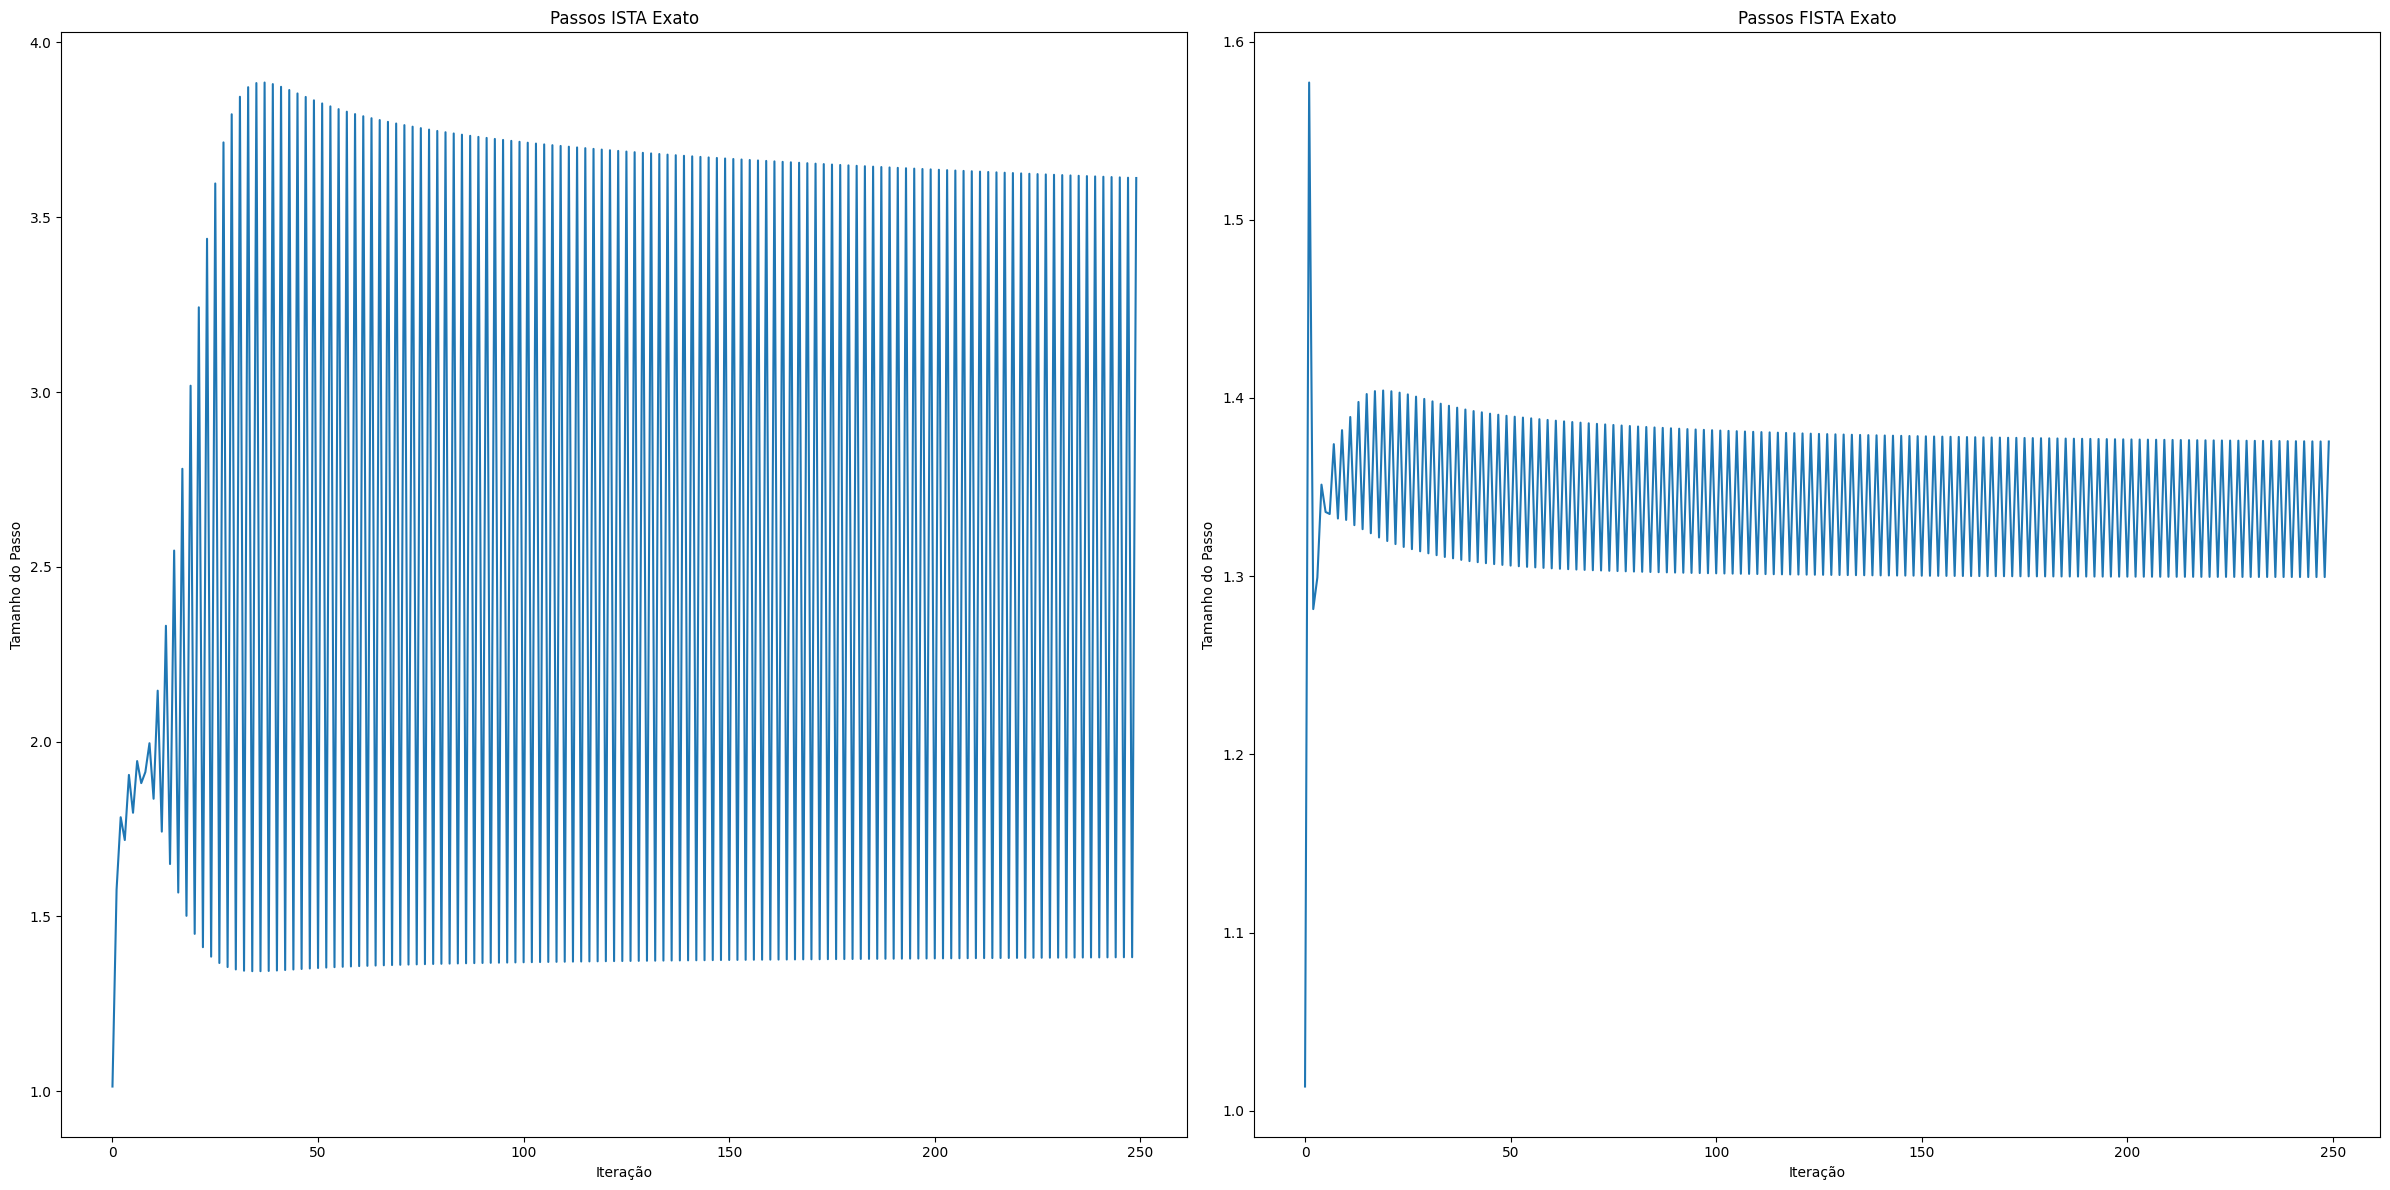

In [20]:
plt.figure( figsize = ( 24, 12 ) )
plt.subplot( 1, 2, 1 )
plt.plot( steps_ista )
plt.title( "Passos ISTA Exato" )
plt.xlabel( "Iteração" )
plt.ylabel( "Tamanho do Passo" )

plt.subplot( 1, 2, 2 )
plt.plot( steps_fista )
plt.title( "Passos FISTA Exato" )
plt.xlabel( "Iteração" )
plt.ylabel( "Tamanho do Passo" )

plt.tight_layout()
plt.show()

Veja que nesse caso para os dois algoritmos o tamanho de passo exato excede o tamanho máximo para o qual os algoritmos têm convergência garantida. 

No caso do ISTA, temos que o tamanho de passo $\lambda < \frac{2}{L} = \frac{2}{0.9997} = 2.0006$ para que a convergência seja garantida.

No caso do FISTA, temos que $\lambda \leq \frac{1}{L} = \frac{1}{0.9997} = 1.0003$.

In [13]:
#vendo o tamanho do passo quando o parametro de regularização é grande para o ista exato
x0 = np.zeros_like( b )
wav = 'db5'
gamma = 0.2 #gamma ótimo
prox = Algorithms.prox_wavelet
max_iter = 200
tol = 1.0e-2

iters_ista_exato, steps_ista = ista_exato( Q = ATA, f = f, grad_f = grad_f, prox = prox, x0 = x0, gamma = gamma, max_iter = max_iter, tol = tol, wavelet = wav )

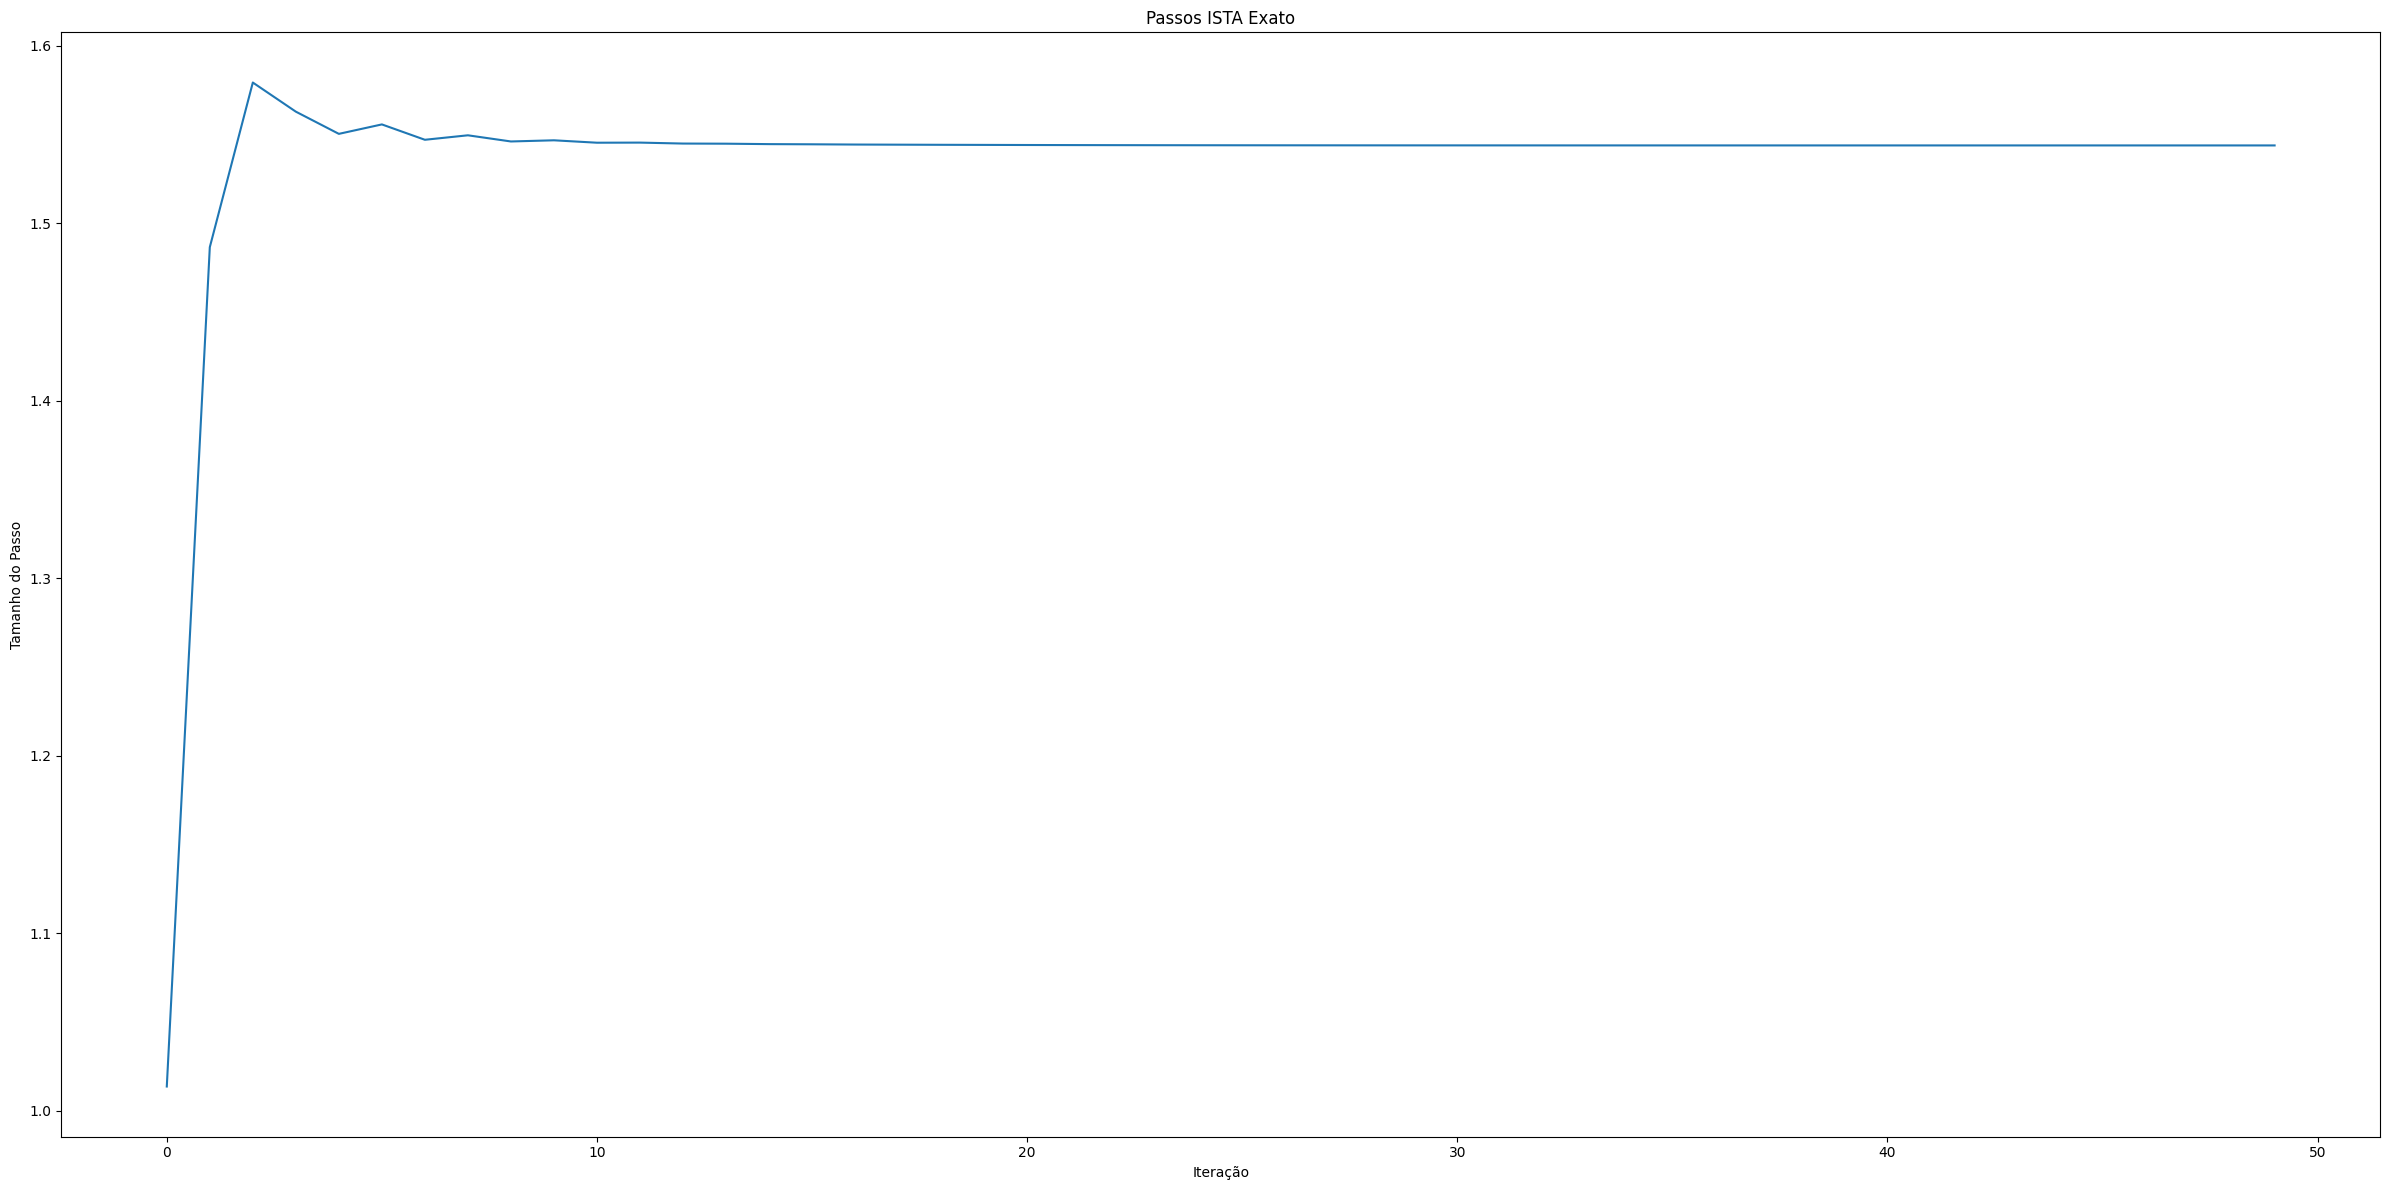

In [14]:
plt.figure( figsize = ( 24, 12 ) )

plt.plot( steps_ista )
plt.title( "Passos ISTA Exato" )
plt.xlabel( "Iteração" )
plt.ylabel( "Tamanho do Passo" )

plt.tight_layout()
plt.show()

Veja que nesse caso o tamanho do passo está dentro do limite para o qual a convergência é garantida. (Porque mexer no valor do parâmetro de regularização influência no tamanho do passo exato?)
